In [1]:
# must pip install required packages
!pip install pygments python-Levenshtein javalang

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.7/162.7 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.7 MB/s eta 0:00:00


In [2]:
#Peace Samuel, 121376141

import os
import ast
import javalang
import re
import hashlib
from pygments import lex
from pygments.lexers import get_lexer_by_name
from pygments.token import Token
from collections import Counter
import math
import Levenshtein

## First Algorithm: MOSS

This class implements the steps in the MOSS plagiarism detection algorithm

In [53]:
class MOSS:
    def __init__(self, code, language, n=20, window_size=4):
        self.og_code = code
        self.language = language
        #self.normalised_text = ""
        self.tokens = []
        self.normalised_tokens = []
        self.k_grams = []
        self.hashes = []
        self.window_size = window_size
        self.n = n
        self.fingerprints = []

# def normalise_text(self):
    #     """
    #     Function to remove any irrelevant features in the text like whitespace, and punctuation
    #     """
    #     #set all text to lowercase and replace remove whitespace
    #     self.normalised_text = re.sub(r'\W+', '', self.og_text.lower())
    #     print("Cleaned text with irrelevant features removed:" + "\n" + self.normalised_text)
    #     return self.normalised_text

    def normalize_code(self):
      """
      Function that uses Pygments to normalize code
      Replaces variable names with T
      Replaces function names with F
      """
      lexer = get_lexer_by_name(self.language)
      tokens = lex(self.og_code, lexer)

      variable_map = {}
      function_map = {}
      normalized_tokens = []

      for token_type, token_value in tokens:
        if token_type in Token.Comment:
          continue  #skip any comments
        elif token_type in Token.Keyword:
          normalized_tokens.append(token_value)#no change for keywords
        elif token_type in Token.Name.Function:
          if token_value not in function_map: #replace function names
            function_map[token_value] = "F"
          normalized_tokens.append(function_map[token_value])
        elif token_type in Token.Name: #replace variable names
          if token_value not in variable_map:
            variable_map[token_value] = "T"
          normalized_tokens.append(variable_map[token_value])
        else:
          normalized_tokens.append(token_value) #keep everything else

      self.og_code = " ".join(normalized_tokens)
      #print(self.og_code)

    def tokenize_code(self):
        """
        Function creates tokens from the code, using the Pygments (removes irrelevant elements)
        """
        lexer = get_lexer_by_name(self.language) #language in this case is java
        raw_tokens = lex(self.og_code, lexer)

        #remove whitespace and comments
        self.tokens = [token_value for token_type, token_value in raw_tokens
                       if token_type not in [Token.Comment, Token.Text.Whitespace]]

        #normalise tokens, covert to lowercase
        self.normalised_tokens = [token.lower() if token.isidentifier() else token for token in self.tokens]
        #print("Tokenized and normalised code: " +"\n"+" ".join(self.normalised_tokens))
        return self.normalised_tokens

    def generate_kgrams(self):
        """
        Function that generates k-grams from the normalised code
        """
        #self.k_grams = [self.normalised_text[i:i + self.n] for i in range(len(self.normalised_text)-self.n +1)]
        self.k_grams = [" ".join(self.normalised_tokens[i:i + self.n])
                        for i in range(len(self.normalised_tokens) - self.n + 1)]

        #print("\n Sequence of 5-grams: \n" + " " .join(self.k_grams))
        return self.k_grams

    def hash_kgrams(self):
        """
        Function that hashes k-grams
        """
        self.hashes = [abs(hash(gram)) % 100 for gram in self.k_grams] #use python hash function
        #print("Sequence of hashes of the 5 grams: \n"+ " ".join(map(str, self.hashes)))
        return self.hashes

    def create_windows(self):
        """
        Function that creates windows of a fixed sized on the hashed k-grams
        """
        windows = [self.hashes[i:i + self.window_size] for i in range(len(self.hashes) -  self.window_size+1)]
        #print("\n Windows of hashes of length 4:")
        # for window in windows:
        #     print(tuple(window))
        return windows

    def winnowing(self):
        """
        Function that uses the winnowing method for fingerprinting (select hash windows based on the minimum has in each window)
        """
        windows = self.create_windows() # call the function to create the windows
        last_pos = None
        for i, window in enumerate(windows):
            min_hash = min(window)
            min_index = i + window.index(min_hash)
            if last_pos is None or self.fingerprints[-1][0] != min_hash:
                self.fingerprints.append((min_hash, min_index))
                last_pos = min_index

        # print("\n Fingerprints selected by winnowing:")
        # print(" ".join(f"[{h},{p}]" for h, p in self.fingerprints))

        # print("\n Fingerprints selected by winnowing:"+ " ".join(f"[{h},{p}]" for h, p in self.fingerprints))
        return self.fingerprints


    def run(self):
        """
        Function that runs all steps
        """
        #print(f"Original code:\n{self.og_code}")
        self.normalize_code()
        self.tokenize_code()
        self.generate_kgrams()
        self.hash_kgrams()
        self.winnowing()
        #return self.fingerprints #explicitly returns the fingerprints for comparison


## Create Comparator classes

These various comparator classes can be used alongside a plagiarism detection algorithm to return the degree of similarity between two source code

### Comparator: Jaccard Similarity

In [54]:
class Comparator:
    def __init__(self, moss_instance_1, moss_instance_2):
        """
            Initializes the Jaccard Similarity Comparator with two MOSS instances
            This works by computing the intersection of tokens between the two sets and dividing by the total number of tokens
        """
        self.moss1 = moss_instance_1
        self.moss2 = moss_instance_2

    def compare(self):
        """
        Function compares the fingerprints of two MOSS objects and calculates a similarity score
        """
        #extract fingerprints
        fingerprints1 = self.moss1.fingerprints
        fingerprints2 = self.moss2.fingerprints

        #convert fingerprints into sets of hashes
        set1 = set()
        for fp in fingerprints1:
            set1.add(fp[0])

        set2 = set()
        for fp in fingerprints2:
            set2.add(fp[0])

        #find common hashes
        common_fingerprints = set1.intersection(set2)

        #calculate similarity score
        total_fingerprints = len(set1.union(set2))
        similarity_score = len(common_fingerprints) / total_fingerprints * 100 #if total_fingerprints > 0 else 0

        #print results
        #print(f"Jaccard Similarity score: {similarity_score:.2f}%")

        return similarity_score, common_fingerprints

### Comparator: Cosine Similarity

In [ ]:
class Comparator2:
    def __init__(self, moss_instance_1, moss_instance_2):
        """
            Initializes the Cosine Similarity Comparator with two MOSS instances
        """
        self.moss1 = moss_instance_1
        self.moss2 = moss_instance_2

    def calculate_cosine_similarity(self, fingerprints1, fingerprints2):
        """
        Calculates the cosine similarity between two sets of fingerprints
        """
        #count the occurrences of each fingerprint (to form the vector)
        vector1 = Counter(fingerprints1)
        vector2 = Counter(fingerprints2)

        #get the unique set of all fingerprints
        all_fingerprints = set(vector1.keys()).union(set(vector2.keys()))

        #compute the dot product and magnitude of vectors
        dot_product = sum(vector1[fp] * vector2[fp] for fp in all_fingerprints)
        magnitude1 = math.sqrt(sum(count ** 2 for count in vector1.values()))
        magnitude2 = math.sqrt(sum(count ** 2 for count in vector2.values()))

        #avoid division by zero
        if magnitude1 == 0 or magnitude2 == 0:
            return 0.0

        #calculate cosine similarity
        return dot_product / (magnitude1 * magnitude2)

    def compare(self):
        """
        Compares the fingerprints of the two MOSS instances to calculate similarity using Cosine Similarity
        """
        #loop through the fingerprints and append the first element
        fingerprints1 = []
        fingerprints2 = []
        for fp in self.moss1.fingerprints:
            fingerprints1.append(fp[0])

        for fp in self.moss2.fingerprints:
            fingerprints2.append(fp[0])


        #calculate cosine similarity
        similarity_score = self.calculate_cosine_similarity(fingerprints1, fingerprints2)
        print(f"Cosine Similarity Score: {similarity_score:.2f}")
        return similarity_score

### Comparator: Levenshtein Similarity

In [ ]:
class Comparator3:
    def __init__(self, moss_instance_1, moss_instance_2):
        """
        Initializes the Levenshtein Comparator with two MOSS instances
        """
        self.moss1 = moss_instance_1
        self.moss2 = moss_instance_2

    def get_fingerprint_string(self, fingerprints):
        """
        Converts a list of fingerprints into a single string for comparison
        """
        fingerprint_strings = []
        for fp in fingerprints:
            fingerprint_strings.append(str(fp[0]))
        return " ".join(fingerprint_strings)

    def calculate_levenshtein_similarity(self):
        """
        Calculates the Levenshtein similarity based on the MOSS fingerprints
        """
        #run MOSS to generate fingerprints
        fingerprints1 = self.moss1.fingerprints
        fingerprints2 = self.moss2.fingerprints

        #convert fingerprints to strings
        fingerprint_str1 = self.get_fingerprint_string(fingerprints1)
        fingerprint_str2 = self.get_fingerprint_string(fingerprints2)

        #calculate Levenshtein distance
        distance = Levenshtein.distance(fingerprint_str1, fingerprint_str2)
        max_length = max(len(fingerprint_str1), len(fingerprint_str2))

        #normalize similarity to range [0, 1]
        similarity = 1 - (distance / max_length) if max_length > 0 else 1.0
        return similarity

    def compare(self):
        """
        Compares the two MOSS instances using Levenshtein similarity
        """
        similarity_score = self.calculate_levenshtein_similarity()
        print(f"Levenshtein Similarity Score: {similarity_score:.2f}")
        return similarity_score

## Run examples, Testing functionality:

In [55]:
#code samples
code1 = """
import java.util.Scanner;

public class T2 {
	public static void main(String[] args) {
		Scanner input = new Scanner(System.in);

		// Enter radius of the cylinder
		System.out.print("Enter the radius and length of a cylinder: ");
		double radius = input.nextDouble();
		double length = input.nextDouble();

		double area = radius * radius * 3.14159;
		double volume = area * length;

		System.out.println("The area is " + area);
		System.out.println("The volume of the cylinder is " + volume);
	}

}
"""

code2 = """
import java.util.Scanner;
public class T02
{
   public static void main(String[] args)
   {
      Scanner sc = new Scanner(System.in);
      System.out.print("Enter the radius and length of a cylinder: ");
      String radlen= sc.nextLine();
      String[] splited = radlen.split("\\s+");
      float rad = Float.parseFloat(splited[0]);
      float len = Float.parseFloat(splited[1]);
      System.out.println("The area is "+Math.round(rad*rad*3.14159*10000.0)/10000.0);
      System.out.println("The volume is "+Math.round(rad*rad*3.14159*len*10.0)/10.0);

   }
}
"""

code3 = """
import java.util.Scanner;

/**
 *
 * @author 672CAF27F5363DC833BDA5099775E891
 */
public class Main {

    /**
     * @param args the command line arguments
     */
    public static void main(String[] args) {
        System.out.print("Enter the radius and length of a cylinder:");
        Scanner sc = new Scanner(System.in);
        double radius = sc.nextDouble();
        int length = sc.nextInt();
        double area = radius*radius*3.14159;
        double volume = length*radius;
        System.out.println("The area is "+area);
        System.out.println("The volume is "+volume);

    }

}
"""

In [56]:
#create MOSS objects
moss1 = MOSS(code1, "java")
moss2 = MOSS(code3, "java")

#run the MOSS algorithm
moss1.run()
moss2.run()

In [57]:
#Jaccard Similarity
#compare the two objects
comparator = Comparator(moss1, moss2)
similarity_score, matches = comparator.compare()
print("Jaccard Similarity Score: " + str(similarity_score)+"%")

Jaccard Similarity Score: 38.23529411764706%


In [ ]:
# Cosine Similarity
# Create the comparator and compare the two codes
comparator = Comparator2(moss1, moss2)
similarity_score = comparator.compare()

Cosine Similarity Score: 0.90


In [ ]:
#Levenshtein Distance import 'python-levenshtein' library
# Compare using LevenshteinComparator
comparator = Comparator3(moss1, moss2)
similarity_score = comparator.compare()

Levenshtein Similarity Score: 0.74


## Parameter Tuning and Optimisation

- First I will extract the source code data samples from the dataset
- I will use the code samples to find the optimal values for k & w

In [5]:
#extract data from files, MOUNT DRIVE FIRST!!
base_directory = "./drive/My Drive/FYP/IR-Plag-Dataset/case-01"
#base directory, where the code data files are stored

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
#dictionary to hold contents of the files in each category ONLY USING CASE-01
file_contents = {
    'non-plagiarized': [],
    'original': [],
    'plagiarized':[]
}

In [8]:
def read_files_from_directory(directory_path, file_extension = '.java'):
    """
    Function to read files from a given directory path
    """
    file_data = []
    for filename in os.listdir(directory_path):
        if filename.endswith('.java'):
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                content = file.read()
                file_data.append(content)
    return file_data



#read files from each category in the base directory
for category in file_contents.keys():
    directory_path = os.path.join(base_directory, category)
    print(directory_path)
    file_contents[category] = read_files_from_directory(directory_path)


# # Examples to access
# # Assuming that there is at least one original file
original_code = file_contents['original'] #only one item
plagiarized_code = file_contents['plagiarized']  #this is a list of plagiarized files
non_plagiarized_code = file_contents['non-plagiarized']  #this is a list of non-plagiarized files

#print((original_code[0]))
#print((plagiarized_code[0]))
#print((non_plagiarized_code[6]))


./drive/My Drive/FYP/IR-Plag-Dataset/case-01/non-plagiarized
./drive/My Drive/FYP/IR-Plag-Dataset/case-01/original
./drive/My Drive/FYP/IR-Plag-Dataset/case-01/plagiarized


## Find k-grams

using original code and non-plagiarised code, find a value for k that prevents innocent code samples from being flagged as plagiarized, use all case files separately

In [ ]:
import matplotlib.pyplot as plt
from itertools import combinations

class MOSS_KGram_Tuning:
    def __init__(self, code_samples, language, k_values, moss_class):
        self.code_samples = code_samples  #list of plagiarized code samples
        self.language = language #coding language
        self.k_values = k_values  #list of k values to test
        self.similarity_counts = {}  #store similarities for each k
        self.moss_class = moss_class #MOSS class for generating k-grams

    def run_tuning(self):
      """
      Function that runs the k-gram tuning
      """
      for k in self.k_values:
        #print(f"Processing k = {k}:")

        k_gram_set = [] #strores all k-grams for code samples

        #generate k-grams (use MOSS class)
        for code in self.code_samples:
            moss_instance = self.moss_class(code, self.language, n=k) #n is k value
            moss_instance.run()

            kgrams = set(moss_instance.k_grams)
            k_gram_set.append(kgrams)

          #compare all pairs and count similarities
        similarity_count = 0
        for set1, set2 in combinations(k_gram_set, 2):
            similarity = self.similarity_test(set1, set2)
            if similarity > 0.2: #threshold for similarity
              similarity_count += 1

        self.similarity_counts[k] = similarity_count #store result

    def similarity_test(self, set1, set2):
      """
      Computes similarity by finding the intersection/common kgrams between two sets and dividing by the total number of kgrams
      """
      common = set1.intersection(set2)
      total = len(set1.union(set2))
      if not common:
        return 0
      return len(common) / total

    def plot_results(self):
        """
        Function that plots similarities detected vs. k value
        """
        plt.figure(figsize=(10, 5))
        plt.plot(self.similarity_counts.keys(), self.similarity_counts.values(), marker='o', linestyle='-')
        plt.xlabel("K-Gram Size (k)")
        plt.ylabel("Number of Similar Pairs Detected")
        plt.title("Effect of K-Gram Size on Similarity Detection")
        plt.grid(True)
        plt.show()


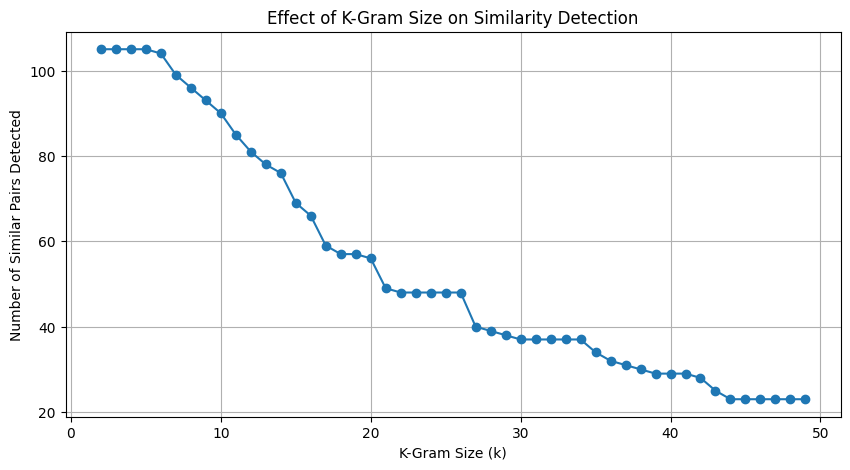

In [ ]:
# original_code
# plagiarized_code
# non_plagiarized_code

# K values to test
k_values = list(range(2, 50))  # Test k from 2 to 50

# Initialize and run the tuning process
tuner = MOSS_KGram_Tuning(non_plagiarized_code,"java", k_values, MOSS)
tuner.run_tuning()
tuner.plot_results()

In [ ]:
import matplotlib.pyplot as plt
from itertools import combinations

class MOSS_Window_Tuning:
    def __init__(self, original_code, plagiarized_samples, non_plagiarized_samples, language, w_values, n=20):
        self.original_code = original_code  #the single original sample
        self.plagiarized_samples = plagiarized_samples  #list of plagiarized versions
        self.non_plagiarized_samples = non_plagiarized_samples  #list of non-plagiarized versions
        self.language = language  #programming language
        self.w_values = w_values  #list of window sizes to test
        self.n = n  #k-gram size
        self.results = {}  #store similarity results

    def compute_fingerprints(self, code, w):
        """ Run MOSS algorithm for a given code and window size w """
        moss = MOSS(code, self.language, n=self.n, window_size=w)
        moss.run()  #generates fingerprints
        return set(fp[0] for fp in moss.fingerprints)  #extract only fingerprint hashes

    def similarity(self, set1, set2):
        """ Compute similarity between two fingerprint sets """
        common = set1.intersection(set2)
        total = len(set1.union(set2))
        if not common:
          return 0
        return len(common) / total
        #return len(set1 & set2) / len(set1 | set2) if set1 | set2 else 0

    def run_tuning(self):
        """ Run parameter tuning for different window sizes (w) """
        for w in self.w_values:
            #print(f"Testing window size w = {w}...")

            #compute fingerprints for original, plagiarized, and non-plagiarized samples
            original_fps = self.compute_fingerprints(self.original_code, w)

            plagiarized_similarities = []
            non_plagiarized_similarities = []

            #compare plagiarized samples
            for sample in self.plagiarized_samples:
                sample_fps = self.compute_fingerprints(sample, w)
                plagiarized_similarities.append(self.similarity(original_fps, sample_fps))

            #compare non-plagiarized samples
            for sample in self.non_plagiarized_samples:
                sample_fps = self.compute_fingerprints(sample, w)
                non_plagiarized_similarities.append(self.similarity(original_fps, sample_fps))

            #store average similarities for this window size
            avg_plagiarized = sum(plagiarized_similarities) / len(plagiarized_similarities)
            avg_non_plagiarized = sum(non_plagiarized_similarities) / len(non_plagiarized_similarities)
            self.results[w] = (avg_plagiarized, avg_non_plagiarized)

    def plot_results(self):
        """ Plot similarity scores for different window sizes """
        w_values = list(self.results.keys())
        plagiarized_scores = [self.results[w][0] for w in w_values]
        non_plagiarized_scores = [self.results[w][1] for w in w_values]

        plt.figure(figsize=(10, 5))
        plt.plot(w_values, plagiarized_scores, marker='o', linestyle='-', label="Plagiarized Similarity")
        plt.plot(w_values, non_plagiarized_scores, marker='o', linestyle='--', label="Non-Plagiarized Similarity")
        plt.xlabel("Window Size (w)")
        plt.ylabel("Average Similarity")
        plt.title("Effect of Window Size on Similarity Detection")
        plt.legend()
        plt.grid(True)
        plt.show()


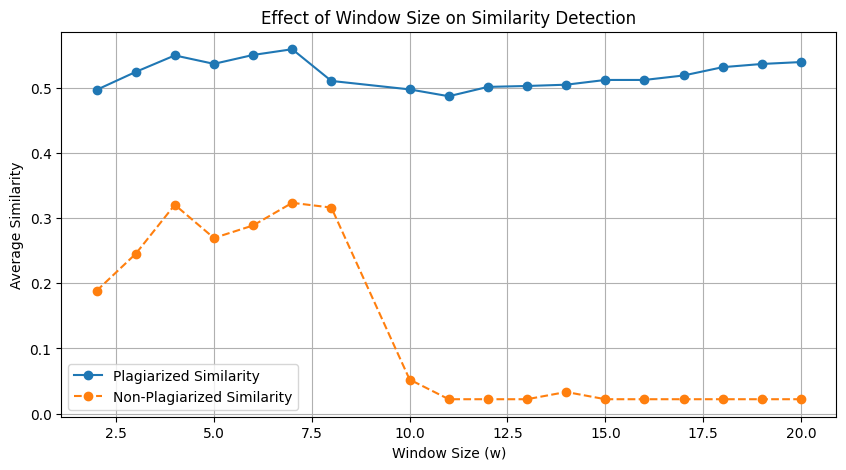

In [ ]:
#define window size values to test
w_values = [2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

#run tuning
tuner = MOSS_Window_Tuning(original_code[0], plagiarized_code, non_plagiarized_code,"java", w_values, n=20)
tuner.run_tuning()
tuner.plot_results()

- [x] Extract files from Google Drive
- [x] Write code to read files from folder
- [x] Need to rearrange the files in each folder (how many to use)
- [x] Need to do some Parameter Tuning for k
- [ ] Need to do some Parameter Tuning for window size

## Test code samples generated using AI

Using code prompt from case samples

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class MOSS_Fingerprint_Comparison:
    def __init__(self, code_samples, language, n=20, window_size=10):
        self.code_samples = code_samples  # List of code samples
        self.language = language
        self.n = n  # K-gram size
        self.window_size = window_size  # Window size for winnowing
        self.moss_instances = []  # Store MOSS instances for each sample
        self.similarity_matrix = None

    def generate_fingerprints(self):
        """Generates fingerprints for each code sample using the MOSS class"""
        for code in self.code_samples:
            moss = MOSS(code, self.language, n=self.n, window_size=self.window_size)
            moss.run()  # Run the full MOSS pipeline for each code sample
            self.moss_instances.append(moss)

    def compute_similarity_matrix(self):
        """Computes the similarity matrix using the Comparator class"""
        num_samples = len(self.moss_instances)
        self.similarity_matrix = np.zeros((num_samples, num_samples))

        for i in range(num_samples):
            for j in range(num_samples):
                if i != j:
                    comparator = Comparator(moss_instance_1=self.moss_instances[i], moss_instance_2=self.moss_instances[j])
                    similarity_score, _ = comparator.compare()
                    self.similarity_matrix[i, j] = similarity_score
                else:
                    self.similarity_matrix[i, j] = 100  # Self-similarity is 100%

    def plot_heatmap(self):
        """Visualizes the similarity matrix using a heatmap"""
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            self.similarity_matrix,
            annot=True,
            cmap="YlGnBu",
            fmt=".2f",
            xticklabels=[f"Code {i+1}" for i in range(len(self.code_samples))],
            yticklabels=[f"Code {i+1}" for i in range(len(self.code_samples))],
            vmin=0, vmax=100
        )
        plt.title("Code Similarity Heatmap (Similarity %)")
        plt.xlabel("Code Samples")
        plt.ylabel("Code Samples")
        plt.show()

    def run(self):
        """Run all steps for comparison and visualization."""
        self.generate_fingerprints()
        self.compute_similarity_matrix()
        self.plot_heatmap()

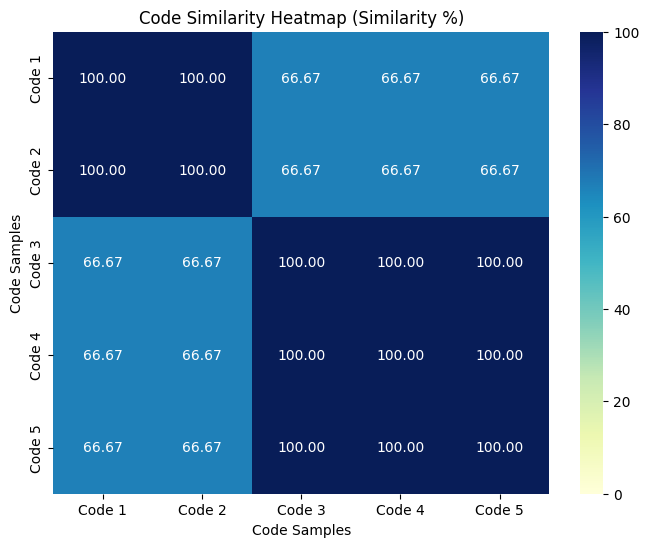

In [62]:
# Example usage:
code_samples = [
    """public class A { public static void main(String[] args) { System.out.println("Hello World"); } }""",
    """public class B { public static void main(String[] args) { System.out.println("Hello World"); } }""",
    """public class C { public static void main(String[] args) { System.out.println("Hi World"); } }""",
    """public class D { public static void main(String[] args) { System.out.println("Goodbye World"); } }""",
    """public class E { public static void main(String[] args) { System.out.println("Hello Universe"); } }"""
]

comparison = MOSS_Fingerprint_Comparison(code_samples, "java", n=10, window_size=10)
comparison.run()
# comparison.generate_fingerprints()
# comparison.compute_similarity_matrix()


### Using prompt from Paper (case 02)
Prompt: Write a program that accepts the radius & length of a cylinder and prints the area & volume of that cylinder. All inputs and outputs are real numbers. Cylinder's area = radius * radius * 3.14159, Cylinder's volume = area * length.

In [60]:


directory_path = './drive/My Drive/FYP/AI_Generated_code/case_02'

def read_files_from_directory(directory_path, file_extension = '.java'):
    """
    Function to read files from a given directory path
    """
    # Dictionary to store file names as keys and file contents as values
    java_files_dict = {}
    file_data = []
    for filename in os.listdir(directory_path):
        if filename.endswith('.java'):
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                content = file.read()
                java_files_dict[file_name] = content
                file_data.append(content)
    return java_files_dict, file_data

dictionary_ , files= read_files_from_directory(directory_path)
for file_name, content in dictionary_.items():
  print(f"File: {file_name} \nContent: {content}\n")
  print('\n' + '-' * 50 + '\n')
#print(files[2])



File: claude_case02.java 
Content: import java.util.Scanner;

public class CylinderCalculator {
    public static void main(String[] args) {
        Scanner input = new Scanner(System.in);

        // Prompt user to enter radius and length
        System.out.print("Enter the radius of the cylinder: ");
        double radius = input.nextDouble();

        System.out.print("Enter the length of the cylinder: ");
        double length = input.nextDouble();

        // Calculate the area and volume
        final double PI = 3.14159;
        double area = radius * radius * PI;
        double volume = area * length;

        // Display results
        System.out.println("The area of the cylinder is " + area);
        System.out.println("The volume of the cylinder is " + volume);

        input.close();
    }
}


--------------------------------------------------



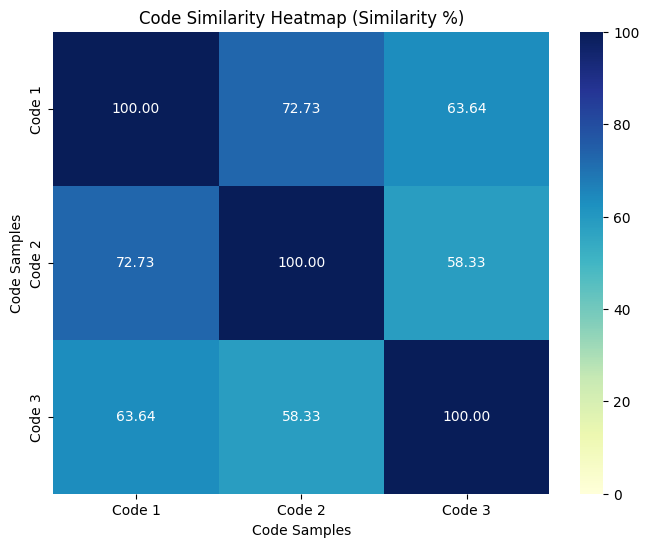

In [61]:
comparison = MOSS_Fingerprint_Comparison(files, "java", n=10, window_size=10)
comparison.run()

## Second Algorithm: Abstract Syntax Tree

This class implements the steps in the ABST plagiarism detection algorithm

In [ ]:
class AbstractSyntaxTree:
  def __init__(self, code, language):
    self.code = code
    self.language = language
    self.tree = self.parse_code()

  def parse_code(self):
    """ function to parse code depending on the language into a AST"""
    if self.language == 'python':
      return ast.parse(self.code)
    elif self.language == 'java':
      return javalang.parse.parse(self.code)
    else:
      raise ValueError('unsupported language')

  def visit(self, node=None, level=0):
      """ function to visit each node in the AST and print a representation"""
      if node is None:
        node = self.tree

      if self.language == 'python':
        if not isinstance (node, ast.AST):
          return
        print('  ' * level + type(node).__name__)
        for field, value in ast.iter_fields(node):
            if isinstance(value, list):
                for item in value:
                    self.visit(item, level=level+1)
            elif isinstance(value, ast.AST):
                self.visit(value, level=level+1)
      elif self.language == 'java':
        if isinstance(node, javalang.ast.Node):
            print('  ' * level + node.__class__.__name__)
            for child in node.children:
                self.visit(child, level=level+1)

  def print_tree(self):
    self.visit()

In [ ]:
# Example usage for Python code
python_code = """
def add(a, b):
    return a + b
"""

# Example usage for Java code
java_code = """
public class HelloWorld {
    public static void main(String[] args) {
        System.out.println("Hello, World!");
    }
}
"""

In [ ]:
python_ast = AbstractSyntaxTree(python_code, 'python')
python_ast.print_tree()

Module
  FunctionDef
    arguments
      arg
      arg
    Return
      BinOp
        Name
          Load
        Add
        Name
          Load


In [ ]:
java_ast = AbstractSyntaxTree(java_code, 'java')
#print(java_ast.print_tree()) #max recursion depth
#java_ast.print_tree()
#recursion error